In [11]:
#Used to run the THM prototype class and compare the results with a reference THM_DONJON case.
#Authors : Clement Huet

from THM_main import Version5_THM_prototype
from iapws import IAPWS97
import numpy as np
from THM_main import plotting
import pandas as pd
import matplotlib.pyplot as plt
# Begining of the script used to test the THM prototype class.

compute_case_transient = False
compute_case_real = False
compute_case_genfoam_OLD_Ex1_12223  = False
compute_case_genfoam_NEW_Ex1_12223  = False
compute_case_genfoam_comparaison_numericalMethod = False
compute_case_genfoam_comparaison_P2Pcorel = False
compute_case_genfoam_comparaison_frfaccorel = False
compute_case_genfoam_comparaison_voidFractionCorrel = False
compute_case_paths = False
compute_case_multiphysics = False
compute_case_BFBT = False
compute_case_compare_power = False
compute_case_compare_Dh = True



if compute_case_compare_Dh:
    rw_list = [0.011, 0.012, 0.013, 0.014, 0.015, 0.016] #0.017, 0.018, 0.019, 0.020]
    D_h = []
    Vf = []
    Vc=[]
    dict_results ={
    }
    for j in range(len(rw_list)):
        case_name = "genfoam_comparaison_Dh"
        #User choice:
        solveConduction = False
        plot_at_z1 = [0.8]

        ########## Thermal hydraulics parameters ##########
        ## Geometric parameters
        canalType = "square"
        waterRadius = rw_list[j] # m  0.0133409 # m #cote or radius if cylindrical
        fuelRadius = 0.00542310/2 # m : fuel rod radius
        gapRadius = fuelRadius + 0.0000000001  # m : expansion gap radius : "void" between fuel and clad - equivalent to inner clad radius
        cladRadius =  0.0094996/2 # m : clad external radius
        height = 1.655 # m : height : active core height in BWRX-300 SMR

        ## Fluid parameters
        pOutlet = 14719781.65 # Pa
        tInlet = 592.75 #K
        u_inlet = 4.467092221 #m/s
        pressureDrop = 186737 #Pa/m
        falsePInlet = pOutlet - height * pressureDrop
        rhoInlet = IAPWS97(T = tInlet, P = falsePInlet*10**(-6)).rho #kg/m3
        flowArea = waterRadius ** 2 - np.pi * cladRadius ** 2
        qFlow = u_inlet * rhoInlet * flowArea # kg/m^2/s

        ## Meshing parameters:
        If = 8
        I1 = 3
        Iz1 = 20 # number of control volumes in the axial direction

        ## Thermalhydraulics correlation
        voidFractionCorrel = "EPRIvoidModel"
        frfaccorel = "Churchill"
        P2Pcorel = "MNmodel"
        numericalMethod = 'FVM'

        ############ Nuclear Parameters ###########
        ## Fission parameters
        qFiss = 1943301220 # W/m3

        ## Material parameters
        kFuel = 4.18 # W/m.K, TECHNICAL REPORTS SERIES No. 59 : Thermal Conductivity of Uranium Dioxide, IAEA, VIENNA, 1966
        Hgap = 10000
        kClad = 21.5 # W/m.K, Thermal Conductivity of Zircaloy-2 (as used in BWRX-300) according to https://www.matweb.com/search/datasheet.aspx?MatGUID=eb1dad5ce1ad4a1f9e92f86d5b44740d
        # k_Zircaloy-4 = 21.6 W/m.K too so check for ATRIUM-10 clad material but should have the same thermal conductivity
        ########## Algorithm parameters ###########
        nIter = 1000
        tol = 1e-4

        Qfiss1 = []
        for i in range(Iz1): 
            if i*(height/Iz1) < 0.1:
                Qfiss1.append(0)
            else:
                Qfiss1.append(qFiss)
        print(Qfiss1)
            
        voidFractionCorrel= "EPRIvoidModel"
        case1 = Version5_THM_prototype(case_name, canalType,
                    waterRadius, fuelRadius, gapRadius, cladRadius, height, tInlet, pOutlet, qFlow, Qfiss1,
                    kFuel, Hgap, kClad, Iz1, If, I1, plot_at_z1, solveConduction,
                    dt = 0, t_tot = 0, frfaccorel = frfaccorel, P2Pcorel = P2Pcorel, voidFractionCorrel = voidFractionCorrel, numericalMethod = numericalMethod)
        D_h.append(case1.convection_sol.D_h)
        Vf.append((np.pi*fuelRadius**2)/(waterRadius**2))
        Vc.append((np.pi*cladRadius**2)/(waterRadius**2))
        voidFractionCorrel= "GEramp"
        case2 = Version5_THM_prototype(case_name, canalType,
                    waterRadius, fuelRadius, gapRadius, cladRadius, height, tInlet, pOutlet, qFlow, Qfiss1,
                    kFuel, Hgap, kClad, Iz1, If, I1, plot_at_z1, solveConduction,
                    dt = 0, t_tot = 0, frfaccorel = frfaccorel, P2Pcorel = P2Pcorel, voidFractionCorrel = voidFractionCorrel, numericalMethod = numericalMethod)

        voidFractionCorrel= "modBestion"
        case3 = Version5_THM_prototype(case_name, canalType,
                    waterRadius, fuelRadius, gapRadius, cladRadius, height, tInlet, pOutlet, qFlow, Qfiss1,
                    kFuel, Hgap, kClad, Iz1, If, I1, plot_at_z1, solveConduction,
                    dt = 0, t_tot = 0, frfaccorel = frfaccorel, P2Pcorel = P2Pcorel, voidFractionCorrel = voidFractionCorrel, numericalMethod = numericalMethod)

        voidFractionCorrel= "HEM1"
        case4 = Version5_THM_prototype(case_name, canalType,
                    waterRadius, fuelRadius, gapRadius, cladRadius, height, tInlet, pOutlet, qFlow, Qfiss1,
                    kFuel, Hgap, kClad, Iz1, If, I1, plot_at_z1, solveConduction,
                    dt = 0, t_tot = 0, frfaccorel = frfaccorel, P2Pcorel = P2Pcorel, voidFractionCorrel = voidFractionCorrel, numericalMethod = numericalMethod)
        
        plotter = plotting([case1, case2, case3, case4])
        #plotter.plotComparison("numericalMethod", [True, True, True, True, True, True, True])
        genFoamVolumeFraction = 0.5655077285
        #plotter.GenFoamComp(r"C:\Users\cleme\OneDrive\Documents\Poly\BWR\driftFluxModel\thermalHydraulicsTransitoire\results.xlsx", 'voidFractionCorrel', [True, True, True, True, True, True], genFoamVolumeFraction)
        #plotter.compute_error(r"C:\Users\cleme\OneDrive\Documents\Poly\BWR\driftFluxModel\thermalHydraulicsTransitoire\results.xlsx", "voidFractionCorrel", genFoamVolumeFraction)
    
        dict_results[case1.convection_sol.D_h] = [case1.convection_sol.voidFraction[-1], case2.convection_sol.voidFraction[-1], case3.convection_sol.voidFraction[-1], case4.convection_sol.voidFraction[-1]]


[0, 0, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220, 1943301220]
$$$---------- THM: prototype, case treated : genfoam_comparaison_Dh.
$$$---------- THM: prototype, steady state case.
$$---------- Calling DFM class.
Setting up heat convection solution along the axial dimension. zmax = 1.655 m with 20 axial elements.
self.I_z: 20
self.qFlow: 0.15183308604650908
self.pOutlet: 14719781.65
self.Lf: 1.655
self.r_f: 0.00271155
self.clad_r: 0.0047498
self.r_w: 0.011
self.Dz: 0.08275
self.dt: 0
Courant number: 0.0
Numerical Method FVM
Hydraulic diameter: 0.003867287006176882
Velocity at inlet: 0.0001518330860465091 m/s
Fission power fluid
Inside resolveInversion
Inside resolveInversion
Convergence test, residuals: epsilon: 1.1841215125157374, rho: 1.8178738878392808, xTh: 3.995834690320707
Inside resolveInversion
Inside resolveInversion
Co

Convergence test, residuals: epsilon: 1.5963678517422568, rho: 3.141555761004458, xTh: 3.995832468145288
Inside resolveInversion
Inside resolveInversion
Convergence test, residuals: epsilon: 0.006527332953764467, rho: 0.007341877988258022, xTh: 0.003086531453005451
Inside resolveInversion
Inside resolveInversion
Convergence test, residuals: epsilon: 0.022786013970018504, rho: 0.02275461128764658, xTh: 0.004895733216550532
Inside resolveInversion
Inside resolveInversion
Convergence test, residuals: epsilon: 0.005072288633294602, rho: 0.007347258686889892, xTh: 0.002770148727333079
Inside resolveInversion
Inside resolveInversion
Convergence test, residuals: epsilon: 0.0001250836950009907, rho: 0.00012093652187939495, xTh: 2.892186245043175e-05
Convergence reached at iteration number: 4
Pressure: [14887550.28073989 14883835.388734   14880120.95033965 14876406.96531897
 14872693.43343442 14868980.35444885 14865267.72812544 14860547.9906177
 14853925.81370332 14846238.41098637 14837572.9954

Convergence test, residuals: epsilon: 0.0057907663739591424, rho: 0.008168301729853038, xTh: 0.0015382667587552031
Inside resolveInversion
Inside resolveInversion
Convergence test, residuals: epsilon: 0.005508848840966029, rho: 0.004534122832405934, xTh: 0.0011526839472247449
Inside resolveInversion
Inside resolveInversion
Convergence test, residuals: epsilon: 0.0011007209211862158, rho: 0.001265360672545086, xTh: 0.00044097917844248375
Inside resolveInversion
Inside resolveInversion
Convergence test, residuals: epsilon: 7.5114882416842874e-06, rho: 9.001729824515388e-06, xTh: 1.2750011947098335e-06
Convergence reached at iteration number: 4
Pressure: [14800595.63486106 14798112.75078454 14795630.0673586  14793147.58451407
 14790665.30218184 14788183.2202929  14785701.33877828 14783219.6575691
 14780738.17659658 14778228.18031969 14774378.45292655 14769987.41314169
 14765134.32739206 14759848.52315775 14754148.04493452 14748045.59571068
 14741550.78322472 14734671.21353205 14727413.102

Convergence test, residuals: epsilon: 0.0014527567935882278, rho: 0.001184492364402629, xTh: 0.0002921828284815437
Inside resolveInversion
Inside resolveInversion
Convergence test, residuals: epsilon: 0.0002397932484143991, rho: 0.0002575098997362734, xTh: 7.432362003029359e-05
Convergence reached at iteration number: 3
Pressure: [14767962.45668338 14766132.38531498 14764302.43273248 14762472.59966059
 14760642.88683625 14758813.29500885 14756983.82494066 14755154.47740713
 14753325.25319716 14751496.15311359 14749667.17797346 14747838.32860846
 14745631.53430122 14742717.54501851 14739512.1891279  14736044.22463764
 14732328.52093397 14728374.95317425 14724190.77875872 14719781.65      ] Pa
Enthalpy: [1451827.49859492 1451824.4868886  1465788.9055154  1479753.32450044
 1493717.74384579 1507682.16355163 1521646.58362127 1535611.00405376
 1549575.4248514  1563539.84601499 1577504.26754557 1591468.68944585
 1605432.17080366 1619393.79226708 1633354.55083613 1647314.44108279
 1661273.4391

Pressure: [14751422.80477762 14749991.30022604 14748559.85952426 14747128.48243587
 14745697.16872599 14744265.9181613  14742834.73051005 14741403.60554216
 14739972.54302915 14738541.54274427 14737110.60446249 14735679.72796058
 14734248.91301708 14732818.15941243 14731387.46692895 14729410.99521042
 14727223.46196823 14724904.82080751 14722421.68268397 14719781.65      ] Pa
Enthalpy: [1451859.88385549 1451857.52913386 1462802.89165233 1473748.25438229
 1484693.6173246  1495638.98047926 1506584.34384717 1517529.70742917
 1528475.07122462 1539420.43523451 1550365.79945963 1561311.1639001
 1572256.52855641 1583201.89342934 1594147.25851911 1605091.41893007
 1616035.00767592 1626978.20294324 1637920.90559211 1648863.10913628] J/kg
Void fraction: [1.00000000e-04 1.00000000e-04 1.00000000e-04 1.00000000e-04
 1.00000000e-04 1.00000000e-04 1.00000000e-04 1.00000000e-04
 1.00000000e-04 1.00000000e-04 1.00000000e-04 1.00000000e-04
 1.00000000e-04 1.00000000e-04 1.00000000e-04 4.62905188e-02
 9

Convergence test, residuals: epsilon: 0.41144638142350654, rho: 0.34959975975570806, xTh: 4.468719156958798
Inside resolveInversion
Inside resolveInversion
Convergence test, residuals: epsilon: 0.0018952828108537549, rho: 0.0017472375607903063, xTh: 0.00042408661811055537
Inside resolveInversion
Inside resolveInversion
Convergence test, residuals: epsilon: 0.0005306615554029261, rho: 0.0005074548658257165, xTh: 4.49798652549049e-05
Convergence reached at iteration number: 2
Pressure: [14742918.32706903 14741753.0856709  14740587.88613574 14739422.7283084
 14738257.61203474 14737092.53716165 14735927.5035371  14734762.51101014
 14733597.55943092 14732432.64865076 14731267.7785221  14730102.94889862
 14728938.15963518 14727773.41058791 14726608.70161424 14725444.03257286
 14724279.40332385 14723114.81372865 14721550.43016435 14719781.65      ] Pa
Enthalpy: [1451876.54837117 1451874.63200126 1460758.51116642 1469642.39047166
 1478526.26991856 1487410.14950555 1496294.02923478 1505177.9091

Inside resolveInversion
Inside resolveInversion
Convergence test, residuals: epsilon: 0.44690961054781536, rho: 0.3774235366428707, xTh: 4.47213595499958
Inside resolveInversion
Inside resolveInversion
Convergence test, residuals: epsilon: 0.0, rho: 0.0003935279033504292, xTh: 0.0
Convergence reached at iteration number: 1
Pressure: [14741729.77356361 14740655.62385293 14739573.32050505 14738482.72896298
 14737383.71127965 14736276.12600317 14735159.82805703 14734034.66861536
 14732900.49497262 14731757.15040771 14730604.47404204 14729442.30069133
 14728270.46071075 14727088.77983304 14725897.07899929 14724695.17418193
 14723482.87619942 14722259.99052243 14721026.31707065 14719781.65      ] Pa
Enthalpy: [1451878.8780134  1451877.11188258 1459271.0580141  1466664.99057045
 1474058.90932334 1481452.81404168 1488846.70448726 1496240.58041556
 1503634.44157685 1511028.28771343 1518422.11856116 1525815.93384964
 1533209.73330031 1540603.51662604 1547997.28353501 1555391.03372433
 1562784.7

D_h: [0.003867287006176882, 0.0054322826203000284, 0.007028436845604805, 0.008652517677463153, 0.010301725169459174, 0.011973621570654605]
Vc: [0.5857538458367075, 0.49219593990445554, 0.4193858896227314, 0.36161334360327346, 0.3150054015388516, 0.2768602161962563]
Vf: [0.19089727830403275, 0.16040674079713862, 0.13667793298691103, 0.11784985038157123, 0.10266031411016872, 0.09022879169839047]


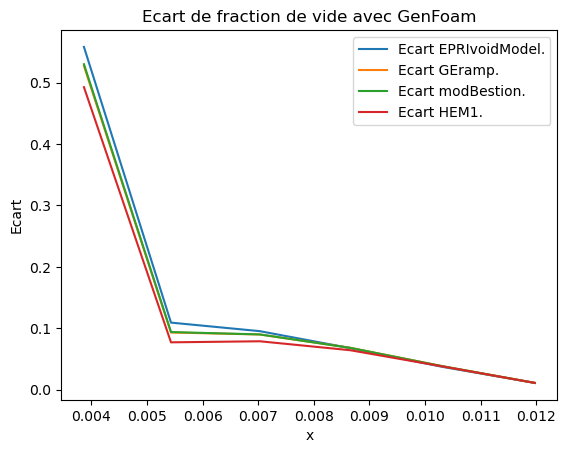

In [13]:
print(f'D_h: {D_h}')
print(f'Vc: {Vc}')
print(f'Vf: {Vf}')
xDFM = case1.convection_sol.z_mesh

# Read the Excel file
df = pd.read_excel(rf'C:\Users\cleme\OneDrive\Documents\Poly\BWR\driftFluxModel\Results\GenFoamComp_Ex1_variation\variation_D_h\GFresults.xlsx')

# Create empty lists for each column
columns = df.columns.tolist()
data = [[] for _ in columns]

# Iterate over each row and append values to the corresponding list
for index, row in df.iterrows():
    for i, col in enumerate(columns):
        data[i].append(row[col])

xGenFoam = data[0]
ecart0=[]
ecart1=[]
ecart2=[]
ecart3=[]
for i in range(len(D_h)):


    # Créer un DataFrame pour la première série
    df1 = pd.DataFrame({'x': xGenFoam, 'y': data[i]})

    # Créer un DataFrame pour la deuxième série
    df2 = pd.DataFrame({'x': xDFM, 'y': dict_results[D_h[i]][0]})
    df3 = pd.DataFrame({'x': xDFM, 'y': dict_results[D_h[i]][1]})
    df4 = pd.DataFrame({'x': xDFM, 'y': dict_results[D_h[i]][2]})
    df5 = pd.DataFrame({'x': xDFM, 'y': dict_results[D_h[i]][3]})

    # Interpolation de la deuxième série sur les abscisses de la première série
    df2_interp = pd.DataFrame({'x': df1['x']})
    df2_interp['y_interp'] = np.interp(df1['x'], df2['x'], df2['y'])

    df3_interp = pd.DataFrame({'x': df1['x']})
    df3_interp['y_interp'] = np.interp(df1['x'], df3['x'], df3['y'])

    df4_interp = pd.DataFrame({'x': df1['x']})
    df4_interp['y_interp'] = np.interp(df1['x'], df4['x'], df4['y'])

    df5_interp = pd.DataFrame({'x': df1['x']})
    df5_interp['y_interp'] = np.interp(df1['x'], df5['x'], df5['y'])

    # Calcul de la différence entre les deux séries
    ecart0.append(np.mean(abs(df1['y'] - df2_interp['y_interp'])))
    ecart1.append(np.mean(abs(df1['y'] - df3_interp['y_interp'])))
    ecart2.append(np.mean(abs(df1['y'] - df4_interp['y_interp'])))
    ecart3.append(np.mean(abs(df1['y'] - df5_interp['y_interp'])))

# Affichage de la différence
fig, ax = plt.subplots()
ax.plot(D_h, ecart0, label=f"Ecart {case1.convection_sol.voidFractionCorrel}.")
ax.plot(D_h, ecart1, label=f"Ecart {case2.convection_sol.voidFractionCorrel}.")
ax.plot(D_h, ecart2, label=f"Ecart {case3.convection_sol.voidFractionCorrel}.")
ax.plot(D_h, ecart3, label=f"Ecart {case4.convection_sol.voidFractionCorrel}.")
ax.set_xlabel("x")
ax.set_ylabel("Ecart")
ax.set_title("Ecart de fraction de vide avec GenFoam")
ax.legend(loc="best")
plt.show()